# **((Modelling and Evaluating))**

## Objectives

* Answer Business Requirement: The client is interested in identifying non malignant and malignant skin cancer in patients through a machine learning application, used as a second opinion.

## Inputs

* inputs/skin_cancer_dataset/melanoma_cancer_dataset/train
* inputs/skin_cancer_dataset/melanoma_cancer_dataset/validation
* inputs/skin_cancer_dataset/melanoma_cancer_dataset/test

## Outputs

* outputs/v1/

## Additional Comments

No additional comments

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/skin-lesion-detector/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/workspaces/skin-lesion-detector'

---

# Data Directories

## Input Directories

Set train, validation, and test set paths so machine knows where the data is

In [4]:
my_data_dir = 'inputs/skin_cancer_dataset/melanoma_cancer_dataset'
train_path = my_data_dir + '/train'
validation_path = my_data_dir + '/validation'
test_path = my_data_dir + '/test'

## Output Directories

Set output directories so the machine knows where to place the outputs

In [5]:
version = 'v1'
file_path = f'outputs/{version}'

if 'outputs' in os.listdir(current_dir) and version in os.listdir(current_dir + '/outputs'):
    print("outputs directory already exists")
    pass
else:
    os.makedirs(file_path)
    print("outputs directory created")

outputs directory already exists


# Set Label Names

Setting label names to know difference

In [6]:
labels = os.listdir(train_path)
print(f"Labels: {labels}")

Labels: ['malignant', 'benign']


# Image Augmentation

Here, we will augment image data. Image augmentation artificially expands your training dataset by creating modified copies of existing images, which helps Convolutional Neural Networks (CNNs) learn more generalized and resilient patterns. It also prevents overfitting

In [7]:
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # This hides the GPU from Tensorflow(Yes, my GPU is bad. This called me poor in ways I did not know you could)

In [8]:
import tensorflow as tf

I0000 00:00:1788661362.568906   92449 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788661364.220350   92449 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788661368.593590   92449 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Importing ImageDataGenerator to be able to augment data. Then, we will initialize the image data generator

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmented_images = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode = 'nearest',
    brightness_range = [0.7, 1.2]
)

Now that we have defined what the image generator will do, we will apply it to the training data only(many mistakes were committed here)

Batch sizes for training data usually are in powers of 2

In [10]:
batch_size = 16
train_set = augmented_images.flow_from_directory(
    directory=train_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

train_set.class_indices

Found 7422 images belonging to 2 classes.


{'benign': 0, 'malignant': 1}

Now we do rescaling for both validation and test sets

In [11]:
validation_set = ImageDataGenerator(rescale=1.0/255.0).flow_from_directory(
    directory=validation_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

validation_set.class_indices

Found 1060 images belonging to 2 classes.


{'benign': 0, 'malignant': 1}

In [12]:
test_set = ImageDataGenerator(rescale=1.0/255.0).flow_from_directory(
    directory=test_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

test_set.class_indices

Found 2123 images belonging to 2 classes.


{'benign': 0, 'malignant': 1}

# Machine Learning Model

Import model packages

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense, Conv2D, MaxPooling2D
from tensorflow.keras import layers, regularizers, models
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [14]:
def create_model():
    model = models.Sequential([
        
        # First block
        layers.Conv2D(16, (3, 3), padding='same', kernel_regularizer=regularizers.l2(5e-4), input_shape=(224,224,3)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),

        #Second block
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer= regularizers.l2(5e-4)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        #Third blok
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        #last block
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # classifier footnote(?) I don't know its proper naming
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(0.5),

        layers.Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=1e-3)
    model.compile(loss='binary_crossentropy',
                  optimizer = optimizer,
                  metrics = ['accuracy'])
    return model


Lets have a look at the model summary

In [15]:
create_model().summary()

/home/cistudent/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1788661397.808927   92449 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 65,697 (256.63 KB)

 Trainable params: 65,217 (254.75 KB)

 Non-trainable params: 480 (1.88 KB)

Well, this is going to take a while to learn. Next, we make sure early stopping is active

In [16]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

And now, we fit the model

In [17]:
model = create_model()
model.fit(train_set,
          epochs=50,
          steps_per_epoch= len(train_set),
          validation_data=validation_set,
          validation_steps= len(validation_set),
          callbacks=[early_stop, reduce_lr],
        #   class_weight={0:1.0, 1:1.0}, # Adjust the weights to balance the classes
          verbose=1
          )

Epoch 1/50


I0000 00:00:1788661404.364538   92449 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
W0000 00:00:1788661408.400051   92919 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1788661408.666309   92919 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1788661408.749063   92919 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1788661408.902709   92918 cpu_allocator_impl.cc:82] Allocation of 25690112 exceeds 10% of free system memory.
W0000 00:00:1788661408.959444   92918 cpu_allocator_impl.cc:82] Allocation of 25690112 exceeds 10% of free system memory.


464/464 ━━━━━━━━━━━━━━━━━━━━ 635s 1s/step - accuracy: 0.7357 - loss: 0.6270 - val_accuracy: 0.6000 - val_loss: 0.7610 - learning_rate: 0.0010
Epoch 2/50
464/464 ━━━━━━━━━━━━━━━━━━━━ 624s 1s/step - accuracy: 0.7776 - loss: 0.5576 - val_accuracy: 0.6472 - val_loss: 0.6521 - learning_rate: 0.0010
Epoch 3/50
464/464 ━━━━━━━━━━━━━━━━━━━━ 700s 1s/step - accuracy: 0.8094 - loss: 0.5000 - val_accuracy: 0.6170 - val_loss: 1.1457 - learning_rate: 0.0010
Epoch 4/50
464/464 ━━━━━━━━━━━━━━━━━━━━ 624s 1s/step - accuracy: 0.8297 - loss: 0.4532 - val_accuracy: 0.7047 - val_loss: 0.7650 - learning_rate: 0.0010
Epoch 5/50
464/464 ━━━━━━━━━━━━━━━━━━━━ 677s 1s/step - accuracy: 0.8352 - loss: 0.4365 - val_accuracy: 0.6594 - val_loss: 0.8620 - learning_rate: 0.0010
Epoch 6/50
464/464 ━━━━━━━━━━━━━━━━━━━━ 556s 1s/step - accuracy: 0.8468 - loss: 0.4127 - val_accuracy: 0.5896 - val_loss: 1.0291 - learning_rate: 0.0010
Epoch 7/50
464/464 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8510 - loss: 0.4108
Epoch 7:

In [18]:
print("\n===== Evaluating on Test Set =====")
test_loss, test_acc = model.evaluate(test_set, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Optional: Get predictions on test set
predictions = model.predict(test_set)
# Convert probabilities to binary classes (threshold 0.5)
predicted_classes = (predictions > 0.5).astype(int)



===== Evaluating on Test Set =====
133/133 ━━━━━━━━━━━━━━━━━━━━ 30s 224ms/step - accuracy: 0.8055 - loss: 0.4858
Test Accuracy: 0.8055
Test Loss: 0.4858
133/133 ━━━━━━━━━━━━━━━━━━━━ 29s 218ms/step


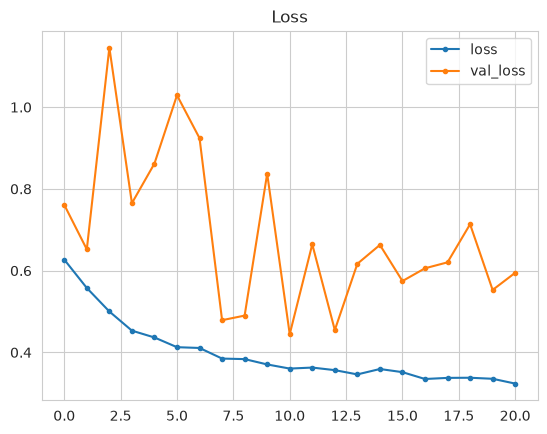

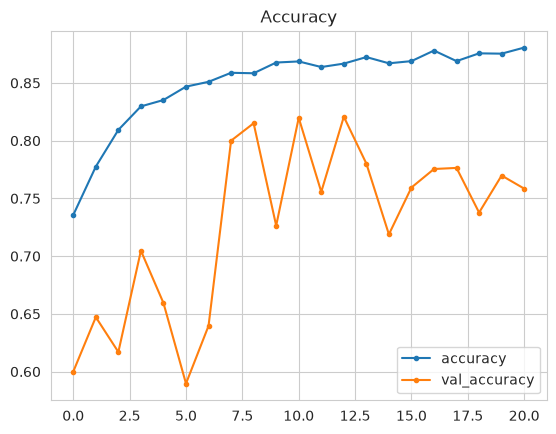

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

losses = pd.DataFrame(model.history.history)

sns.set_style("whitegrid")
losses[['loss', 'val_loss']].plot(style='.-')
plt.title("Loss")
plt.savefig(f'{file_path}/model_training_losses.png',
            bbox_inches='tight', dpi=150)
plt.show()

print("\n")
losses[['accuracy', 'val_accuracy']].plot(style='.-')
plt.title("Accuracy")
plt.savefig(f'{file_path}/model_training_acc.png',
            bbox_inches='tight', dpi=150)
plt.show()

Save the model

In [23]:
model.save(f'{file_path}/melanoma_detector_model.keras')